Saving Mall_Customers.csv to Mall_Customers (5).csv


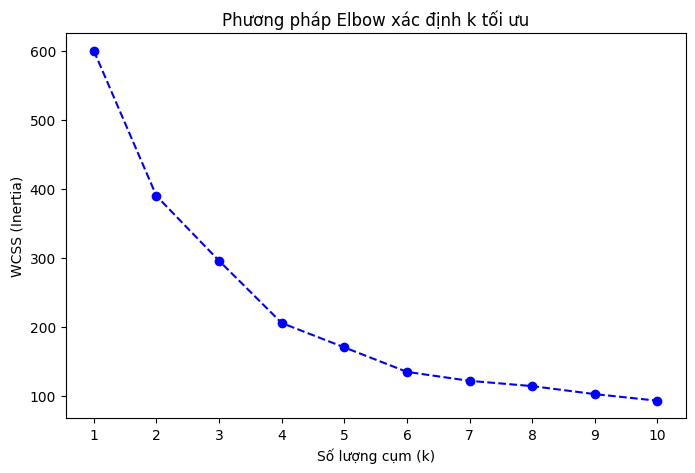

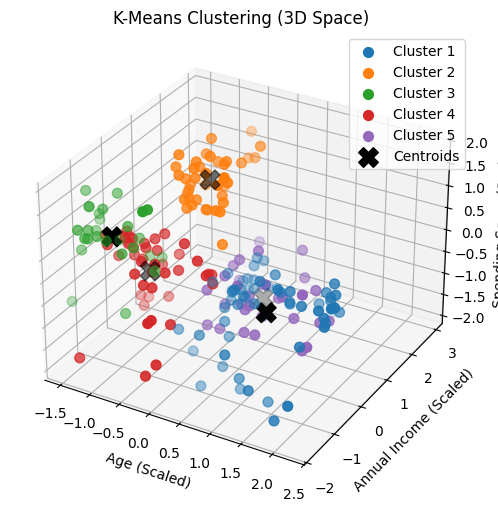

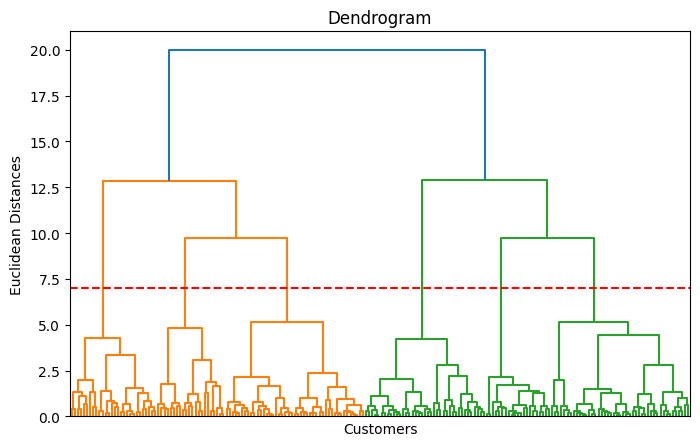

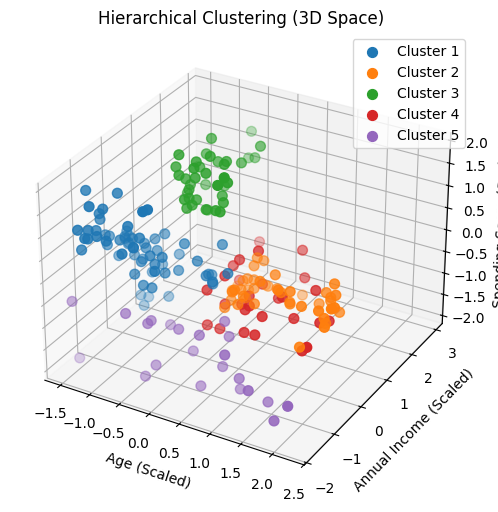

/tmp/ipykernel_553/4019985148.py:112: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  ax.legend()


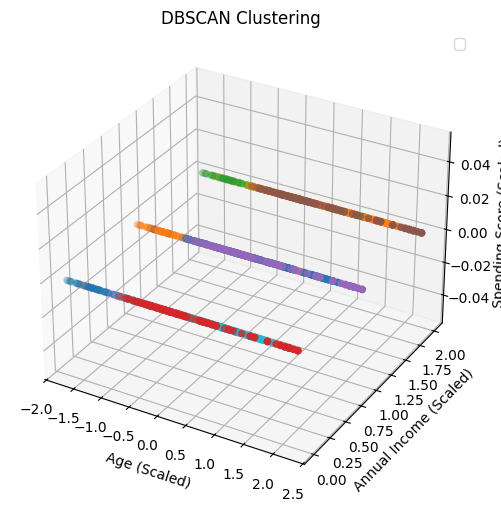

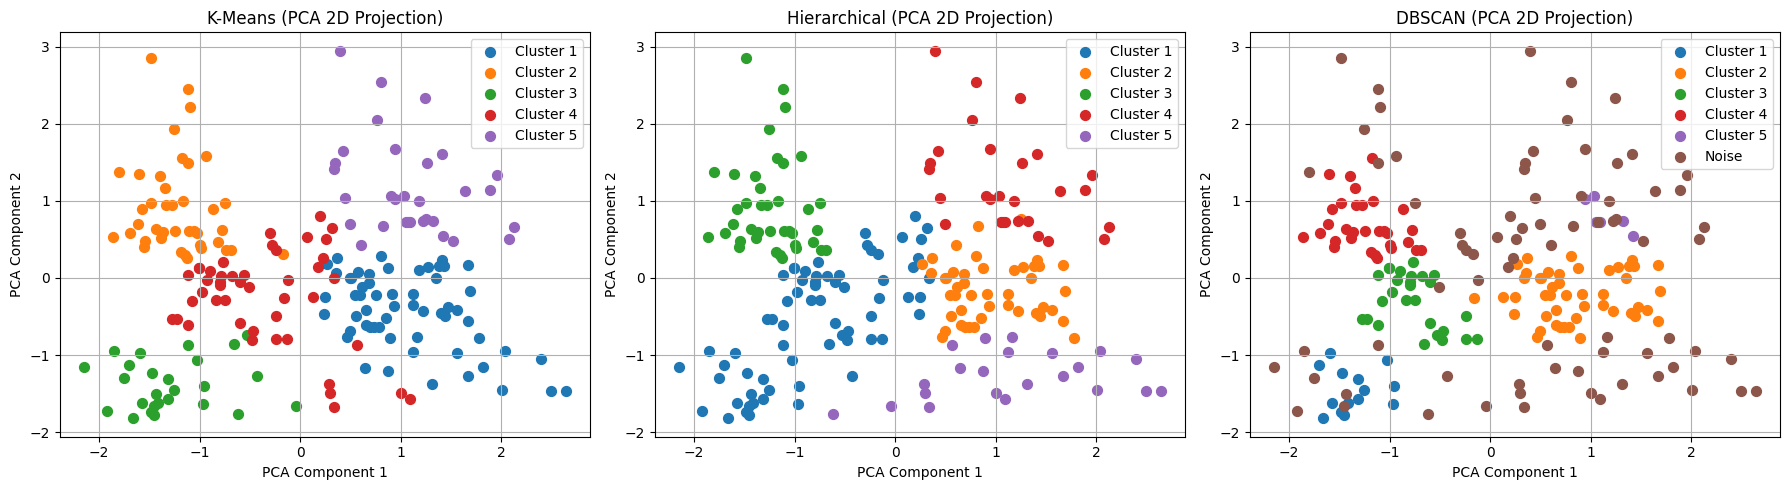

=== BẢNG SO SÁNH CHỈ SỐ SILHOUETTE SCORE (3D) ===
1. K-Means Silhouette Score:               0.4085
2. Hierarchical Clustering Silhouette Score: 0.3900
3. DBSCAN Silhouette Score (trừ nhiễu):      0.5423
-> Tỷ lệ thông tin PCA giữ lại được: 77.57%


In [7]:
import pandas as pd
import numpy as np
from sklearn.preprocessing import StandardScaler
from google.colab import files
from sklearn.cluster import KMeans, AgglomerativeClustering, DBSCAN
import matplotlib.pyplot as plt
import scipy.cluster.hierarchy as sch
from sklearn.decomposition import PCA
from sklearn.manifold import TSNE
from sklearn.metrics import silhouette_score

# Load dữ liệu
uploaded = files.upload()
df = pd.read_csv('Mall_Customers.csv')

# Chọn đặc trưng và chuẩn hóa
X_3d = df[['Age', 'Annual Income (k$)', 'Spending Score (1-100)']].values
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_3d) # Đã sửa X thành X_3d

# Tìm k tối ưu
wcss = []
k_range = range(1, 11)
for k in k_range:
  k_means = KMeans(n_clusters=k, init='k-means++', random_state=42)
  k_means.fit(X_scaled)
  wcss.append(k_means.inertia_)

# Vẽ biểu đồ Elbow
plt.figure(figsize=(8,5))
plt.plot(k_range, wcss, marker='o', linestyle='--', color='b')
plt.title('Phương pháp Elbow xác định k tối ưu')
plt.xlabel('Số lượng cụm (k)')
plt.ylabel('WCSS (Inertia)')
plt.xticks(k_range)
plt.show()

# Chạy KMeans với k tối ưu
k_optimal = 5
k_means = KMeans(n_clusters=k_optimal, init='k-means++', random_state=42)
y_kmeans = k_means.fit_predict(X_scaled)

# Biểu đồ phân cụm K-Means (Vẽ không gian 3D)
fig = plt.figure(figsize=(9, 6))
ax = fig.add_subplot(111, projection='3d')

for i in range(k_optimal):
    ax.scatter(X_scaled[y_kmeans == i, 0],
               X_scaled[y_kmeans == i, 1],
               X_scaled[y_kmeans == i, 2],
               s=50, label=f'Cluster {i+1}')

# Vẽ tâm cụm (Centroids)
ax.scatter(k_means.cluster_centers_[:, 0],
           k_means.cluster_centers_[:, 1],
           k_means.cluster_centers_[:, 2],
           s=200, c='black', marker='X', label='Centroids')

ax.set_title('K-Means Clustering (3D Space)')
ax.set_xlabel('Age (Scaled)')
ax.set_ylabel('Annual Income (Scaled)')
ax.set_zlabel('Spending Score (Scaled)')
ax.legend()
plt.show()

# Xác định số cụm cho Hierarchy Clustering
plt.figure(figsize=(8,5))
dendrogram = sch.dendrogram(sch.linkage(X_scaled, method='ward'), no_labels=True)
plt.axhline(y=7.0, color='r', linestyle='--') # Nâng đường cắt lên y=7.0 cho dữ liệu 3D
plt.title('Dendrogram')
plt.xlabel('Customers')
plt.ylabel('Euclidean Distances')
plt.show()

# Huấn luyện AgglomerativeClustering với n_clusters = 5
hc = AgglomerativeClustering(n_clusters=5, metric='euclidean', linkage='ward')
y_hc = hc.fit_predict(X_scaled)

# Vẽ biểu đồ cho Hierarchy Clustering
fig = plt.figure(figsize=(9, 6))
ax = fig.add_subplot(111, projection='3d')
for i in range(5):
    ax.scatter(X_scaled[y_hc == i, 0],
               X_scaled[y_hc == i, 1],
               X_scaled[y_hc == i, 2],
               s=50, label=f'Cluster {i+1}')

ax.set_title('Hierarchical Clustering (3D Space)')
ax.set_xlabel('Age (Scaled)')
ax.set_ylabel('Annual Income (Scaled)')
ax.set_zlabel('Spending Score (Scaled)')
ax.legend()
plt.show()

# Huấn luyện cho DBSCAN
dbscan = DBSCAN(eps=0.45, min_samples=5)
y_dbscan = dbscan.fit_predict(X_scaled)
n_cluster_db = len(set(y_dbscan)) - (1 if -1 in y_dbscan else 0)
n_db_noise = list(y_dbscan).count(-1)

# Vẽ biểu đồ cho DBSCAN
fig = plt.figure(figsize=(8,6))
ax = fig.add_subplot(111, projection='3d')
for i in range(n_cluster_db):
    ax.scatter(X_scaled[y_dbscan == i], 0)
    ax.scatter(X_scaled[y_dbscan == i], 1)
    ax.scatter(X_scaled[y_dbscan == i], 2)
ax.set_title('DBSCAN Clustering')
ax.set_xlabel('Age (Scaled)')
ax.set_ylabel('Annual Income (Scaled)')
ax.set_zlabel('Spending Score (Scaled)')
ax.legend()
plt.show()

# BƯỚC 4: GIẢM CHIỀU VỀ 2D BẰNG PCA & t-SNE ĐỂ GIẢI THÍCH
# 1. Giảm chiều bằng PCA
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_scaled)

# 2. Giảm chiều bằng t-SNE
tsne = TSNE(n_components=2, random_state=42, perplexity=30)
X_tsne = tsne.fit_transform(X_scaled)

# Vẽ biểu đồ so sánh các thuật toán trên không gian PCA 2D
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# K-Means trên PCA
for i in range(k_optimal):
    axes[0].scatter(X_pca[y_kmeans == i, 0], X_pca[y_kmeans == i, 1], label=f'Cluster {i+1}', s=50)
axes[0].set_title('K-Means (PCA 2D Projection)')
axes[0].set_xlabel('PCA Component 1')
axes[0].set_ylabel('PCA Component 2')
axes[0].legend()
axes[0].grid(True)

# Hierarchical trên PCA
for i in range(5):
    axes[1].scatter(X_pca[y_hc == i, 0], X_pca[y_hc == i, 1], label=f'Cluster {i+1}', s=50)
axes[1].set_title('Hierarchical (PCA 2D Projection)')
axes[1].set_xlabel('PCA Component 1')
axes[1].set_ylabel('PCA Component 2')
axes[1].legend()
axes[1].grid(True)

# DBSCAN trên PCA
for i in set(y_dbscan):
    label_name = 'Noise' if i == -1 else f'Cluster {i+1}'
    axes[2].scatter(X_pca[y_dbscan == i, 0], X_pca[y_dbscan == i, 1], label=label_name, s=50)
axes[2].set_title('DBSCAN (PCA 2D Projection)')
axes[2].set_xlabel('PCA Component 1')
axes[2].set_ylabel('PCA Component 2')
axes[2].legend()
axes[2].grid(True)

plt.tight_layout()
plt.show()

# Đánh giá chất lương phân cụm
sil_kmeans = silhouette_score(X_scaled, y_kmeans)
sil_hc = silhouette_score(X_scaled, y_hc)

# DBSCAN: Chỉ tính các điểm không phải nhiễu (-1)
if len(set(y_dbscan) - {-1}) > 1:
    non_noise_mask = y_dbscan != -1
    sil_dbscan = silhouette_score(X_scaled[non_noise_mask], y_dbscan[non_noise_mask])
else:
    sil_dbscan = -1

print("=== BẢNG SO SÁNH CHỈ SỐ SILHOUETTE SCORE (3D) ===")
print(f"1. K-Means Silhouette Score:               {sil_kmeans:.4f}")
print(f"2. Hierarchical Clustering Silhouette Score: {sil_hc:.4f}")
print(f"3. DBSCAN Silhouette Score (trừ nhiễu):      {sil_dbscan:.4f}")
print(f"-> Tỷ lệ thông tin PCA giữ lại được: {sum(pca.explained_variance_ratio_)*100:.2f}%")



